# YOLO Object Detection

이미지 분류는 이미지 전체에 대해 하나의 정답을 예측하지만, 객체 탐지는 이미지 안에 어떤 객체가 있는지뿐 아니라 그 객체가 어디에 있는지도 함께 예측한다.

YOLO는 You Only Look Once의 약자이다. 이름 그대로 이미지를 여러 단계로 나누어 반복 처리하기보다, 한 번의 추론 과정에서 객체의 위치와 클래스를 빠르게 예측하는 계열의 객체 탐지 모델이다.

## Classification과 Object Detection의 차이

이미지 분류 모델의 출력은 보통 하나의 클래스이다.

예를 들어 SVHN 숫자 이미지를 입력하면 모델은 `0`부터 `9`까지의 클래스 중 하나를 예측한다.

반면 객체 탐지 모델은 다음 정보를 함께 출력한다.

- class: 탐지한 객체의 종류
- confidence: 모델이 해당 객체라고 판단한 확신도
- bounding box: 객체가 위치한 사각형 영역

따라서 객체 탐지는 단순한 분류보다 출력 구조가 복잡하다. 대신 실제 서비스에서는 훨씬 더 넓게 활용된다. 예를 들어 CCTV 사람 감지, 차량 탐지, 상품 진열 상태 확인, 불량품 검사, 웹캠 기반 실시간 인식 등이 객체 탐지 문제에 해당한다.

## Bounding Box, Confidence, IoU, NMS

객체 탐지에서 자주 등장하는 핵심 용어는 다음과 같다.

- Bounding Box: 객체를 둘러싸는 사각형 영역이다.
- Confidence Score: 모델이 해당 박스 안에 객체가 있다고 판단한 확신도이다.
- IoU(Intersection over Union): 두 박스가 얼마나 겹치는지 측정하는 값이다.
- NMS(Non-Maximum Suppression): 같은 객체에 대해 여러 박스가 중복 예측될 때, 가장 적절한 박스만 남기는 후처리 방식이다.

In [9]:
# 필요한 라이브러리를 설치한다.
# - ultralytics: YOLO 모델 로드, 추론, 학습, 평가 기능 제공
# - opencv-python: 이미지/동영상 처리
%pip -q install ultralytics opencv-python

Note: you may need to restart the kernel to use updated packages.


In [10]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Video, display
from ultralytics import YOLO

## 사전학습 YOLO 모델 로드

https://docs.ultralytics.com/ko

https://docs.ultralytics.com/ko/tasks/detect

Ultralytics YOLO는 `YOLO("모델파일.pt")` 형태로 모델을 로드한다.

현재 공식 문서는 YOLO26 계열 예제를 기준으로 `yolo26n.pt`를 사용한다. 여기서 `n`은 nano 모델을 의미하며, 크기가 작아 실습용으로 적합하다.

단, 설치된 ultralytics 버전이나 실행 시점에 따라 제공되는 모델명이 다를 수 있다. 만약 `yolo26n.pt` 다운로드가 실패하면 같은 코드 구조에서 `yolo11n.pt` 또는 `yolov8n.pt`로 바꿔 실행하면 된다.

YOLO의 사전학습 모델은 보통 COCO 데이터셋을 기준으로 학습되어 있다. COCO는 사람, 자동차, 버스, 고양이, 강아지, 의자, 컵, 노트북 등 일상에서 자주 등장하는 객체 80개 클래스를 포함하는 대표적인 객체 탐지 데이터셋이다.

따라서 사전학습 YOLO 모델을 불러오면 별도의 추가 학습 없이도 COCO에 포함된 일반적인 객체를 탐지할 수 있다. `model.names`를 출력하면 현재 모델이 탐지할 수 있는 클래스 번호와 클래스 이름을 확인할 수 있다.

In [11]:
MODEL_NAME = 'yolo26n.pt'

model = YOLO(MODEL_NAME)

# 해당 모델이 사전 학습한 80개의 클래스의 번호와 이름 매핑 확인
print(model.names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

## 이미지 객체 탐지

In [12]:
image_source = 'https://ultralytics.com/images/bus.jpg'

# conf는 confidence threshold로 0.25보다 낮은 예측은 결과에서 제외
results = model.predict(source=image_source, conf=0.25)

print(type(results))
print('결과 개수 : ', len(results))


image 1/1 c:\workspaces2\09_deep_learning_multimodal\01_cnn\bus.jpg: 640x480 4 persons, 1 bus, 466.1ms
Speed: 12.9ms preprocess, 466.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
<class 'list'>
결과 개수 :  1


In [13]:
# results는 이미지별 예측 결과의 리스트로 이미지 1장을 입력했으므로 results[0]에 결과가 담겨 있다.
result = results[0]

print('원본 이미지 경로 :', result.path)
print('탐지 된 박스 수 :', len(result.boxes))
print(result.boxes)

원본 이미지 경로 : c:\workspaces2\09_deep_learning_multimodal\01_cnn\bus.jpg
탐지 된 박스 수 : 5
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([5., 0., 0., 0., 0.])
conf: tensor([0.9236, 0.9126, 0.9055, 0.8701, 0.5345])
data: tensor([[0.0000e+00, 2.2937e+02, 8.0610e+02, 7.5709e+02, 9.2365e-01, 5.0000e+00],
        [2.2247e+02, 4.0494e+02, 3.4541e+02, 8.6164e+02, 9.1261e-01, 0.0000e+00],
        [4.7688e+01, 3.9932e+02, 2.3935e+02, 9.0302e+02, 9.0546e-01, 0.0000e+00],
        [6.7068e+02, 3.9153e+02, 8.0981e+02, 8.7898e+02, 8.7009e-01, 0.0000e+00],
        [1.2922e-01, 5.5669e+02, 6.0004e+01, 8.7010e+02, 5.3447e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([5, 6])
xywh: tensor([[403.0480, 493.2274, 806.0960, 527.7169],
        [283.9376, 633.2928, 122.9362, 456.7037],
        [143.5166, 651.1708, 191.6579, 503.7020],
        [740.2419, 635.2556, 139.1324, 487.4559],
        [ 30.0667, 713.3925,  59.8749, 313.4063]])
xywhn: tensor([[0.49

## 탐지 결과 시각화

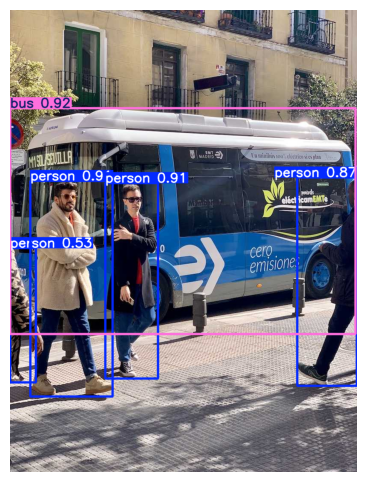

In [14]:
annotated_image = result.plot() # 탐지 된 bounding box와 class 이름이 그려진 이미지를 반환

# OpenCV 계열 출력은 BGR 일 수 있으므로 RGB로 변환해서 matplotlib에 표시
annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(annotated_image_rgb)
plt.axis('off')
plt.show()

## confidence threshold 조정

In [15]:
# confidence threshold를 다르게 주면서 결과 개수를 비교한다.
for conf in [0.1, 0.25, 0.5, 0.7]:
    temp_results = model.predict(source=image_source, conf=conf, verbose=False)
    count = len(temp_results[0].boxes)
    print(f'conf={conf}: 탐지된 객체 수 = {count}')

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
conf=0.1: 탐지된 객체 수 = 7
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
conf=0.25: 탐지된 객체 수 = 5
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
conf=0.5: 탐지된 객체 수 = 5
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
conf=0.7: 탐지된 객체 수 = 4


## 클래스 필터링

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg


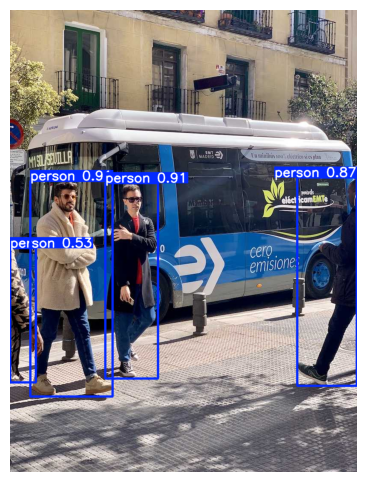

In [16]:
# 사람(person)만 탐지한다.
person_results = model.predict(
    source=image_source,
    conf=0.25,
    classes=[0],        # 클래스 id 목록을 전달하여 특정 클래스만 탐지할 수 있다.
    verbose=False
)

person_image = person_results[0].plot()
person_image_rgb = cv2.cvtColor(person_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(person_image_rgb)
plt.axis('off')
plt.show()

## 동영상 객체 탐지

In [18]:
video_path = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi'

MODEL_NAME = 'yolo26n.pt'
model = YOLO(MODEL_NAME)

results = model(
    video_path,
    save=True,      # 탐지 결과 자동 저장 옵션 
    conf=0.25
)


Found https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi locally at vtest.avi
WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/795) c:\workspaces2\09_deep_learning_multimodal\01_cnn\vtest.avi: 480x640 3 persons, 1 car, 1 truck, 1 bird, 139.0ms
video 1/1 (frame 2/795) c:\workspaces2\09_deep_learning_multimodal\01_cnn\vtest.avi: 480x640 3 persons, 1 car, 1 truck, 143.3ms
video 1/1 (frame 3/795) c:\workspaces2\09_deep_learning_multimodal\01_cnn\vtest.avi: 480x640